# CS465 Project: Gender Bias and Fairness in Machine Learning-Based Loan Approval

## phase 3: Dataset Characterization, Preprocessing, and Exploratory Data Analysis (EDA)

This phase presents the dataset characterization, preprocessing procedures, and exploratory data analysis conducted in this study. It includes:

- Formal dataset characterization  
- Preprocessing steps (data cleaning, missing-value handling, and normalization)  
- Annotation and labeling explanation  
- Exploratory data analysis to identify class imbalance, potential bias, and noise  
- EDA findings that support modeling and evaluation decisions  
- Relation to prior studies  
- Justification of the train-test split and cross-validation strategy  

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier


## 1. Load Dataset


In [4]:
file_path = "loan_data.csv"
raw_df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", raw_df.shape)

Dataset loaded successfully.
Shape: (45000, 14)


## 2. Formal Dataset Characterization
This section provides a description of the dataset:
- size
- structure
- feature types
- class distribution

In [5]:
print("First 5 rows:")
display(raw_df.head())

print("\nColumn names:")
print(list(raw_df.columns))

print("\nData types:")
display(raw_df.dtypes.to_frame(name="dtype"))

print("\nDataset info:")
raw_df.info()

First 5 rows:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1



Column names:
['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']

Data types:


,dtype
person_age,float64
person_gender,object
person_education,object
person_income,float64
person_emp_exp,int64
person_home_ownership,object
loan_amnt,float64
loan_intent,object
loan_int_rate,float64
loan_percent_income,float64



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_def

In [6]:
target_col = "loan_status"

numerical_cols = raw_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = raw_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

if target_col in numerical_cols:
    numerical_feature_cols = [c for c in numerical_cols if c != target_col]
else:
    numerical_feature_cols = numerical_cols.copy()

print("Number of instances:", raw_df.shape[0])
print("Number of total attributes:", raw_df.shape[1])
print("Number of input features:", raw_df.shape[1] - 1)
print("Target column:", target_col)

print("\nNumerical feature columns:")
print(numerical_feature_cols)

print("\nCategorical feature columns:")
print(categorical_cols)

Number of instances: 45000
Number of total attributes: 14
Number of input features: 13
Target column: loan_status

Numerical feature columns:
['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

Categorical feature columns:
['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [7]:
print("Descriptive statistics for numerical columns:")
display(raw_df[numerical_feature_cols + [target_col]].describe().T)

class_counts = raw_df[target_col].value_counts().sort_index()
class_percent = raw_df[target_col].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percent.round(2)
})

print("Target distribution:")
display(class_summary)

Descriptive statistics for numerical columns:


,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


Target distribution:


,count,percentage
loan_status,,
0,35000,77.78
1,10000,22.22


## 3. Cleaning Checks

A clean preprocessing section check:
- duplicate rows
- missing values
- invalid or unrealistic values
- category consistency

In [8]:
print("Duplicate rows:", raw_df.duplicated().sum())

print("\nMissing values before handling:")
display(raw_df.isnull().sum().to_frame(name="missing_count"))

print("\nUnique values in categorical columns:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(sorted(raw_df[col].dropna().unique()))

Duplicate rows: 0

Missing values before handling:


,missing_count
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0



Unique values in categorical columns:

person_gender:
['female', 'male']

person_education:
['Associate', 'Bachelor', 'Doctorate', 'High School', 'Master']

person_home_ownership:
['MORTGAGE', 'OTHER', 'OWN', 'RENT']

loan_intent:
['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']

previous_loan_defaults_on_file:
['No', 'Yes']


In [9]:
# Basic data quality checks were performed on key numerical features.
validity_checks = {
    "person_age <= 0": int((raw_df["person_age"] <= 0).sum()),
    "person_age > 100": int((raw_df["person_age"] > 100).sum()),
    "person_income < 0": int((raw_df["person_income"] < 0).sum()),
    "loan_amnt < 0": int((raw_df["loan_amnt"] < 0).sum()),
    "loan_percent_income < 0": int((raw_df["loan_percent_income"] < 0).sum()),
    "loan_percent_income > 1": int((raw_df["loan_percent_income"] > 1).sum()),
    "credit_score < 0": int((raw_df["credit_score"] < 0).sum()),
    "credit_score > 850": int((raw_df["credit_score"] > 850).sum()),
    "person_emp_exp < 0": int((raw_df["person_emp_exp"] < 0).sum()),
    "person_emp_exp > person_age": int((raw_df["person_emp_exp"] > raw_df["person_age"]).sum()),
    "cb_person_cred_hist_length < 0": int((raw_df["cb_person_cred_hist_length"] < 0).sum()),
    "cb_person_cred_hist_length > person_age": int((raw_df["cb_person_cred_hist_length"] > raw_df["person_age"]).sum())
}

print("Basic validity checks:")
for k, v in validity_checks.items():
    print(f"{k}: {v}")

Basic validity checks:
person_age <= 0: 0
person_age > 100: 7
person_income < 0: 0
loan_amnt < 0: 0
loan_percent_income < 0: 0
loan_percent_income > 1: 0
credit_score < 0: 0
credit_score > 850: 0
person_emp_exp < 0: 0
person_emp_exp > person_age: 0
cb_person_cred_hist_length < 0: 0
cb_person_cred_hist_length > person_age: 0


## 4. Missing-Value Handling

The dataset does not have missing values, but we still included a basic strategy in the preprocessing step to handle them if they appear later. Numerical features are filled using the mean, while categorical features are filled using the most common value.

In [10]:
df = raw_df.copy()

for col in numerical_feature_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after handling:")
display(df.isnull().sum().to_frame(name="missing_count"))

Missing values after handling:


,missing_count
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


## 5. Annotation / Labeling

This is a supervised learning dataset because it already contains a target label called `loan_status`.

- `loan_status` is the prediction target
- the remaining columns are input features
- gender is treated as a protected attribute for fairness analysis
- labels are provided by the dataset and are not manually created in this notebook

## 6. Exploratory Data Analysis (EDA)

This EDA is designed to:
- identify class imbalance
- examine possible gender-related disparities
- inspect feature distributions
- inspect noise and outliers
- support later modeling and evaluation decisions

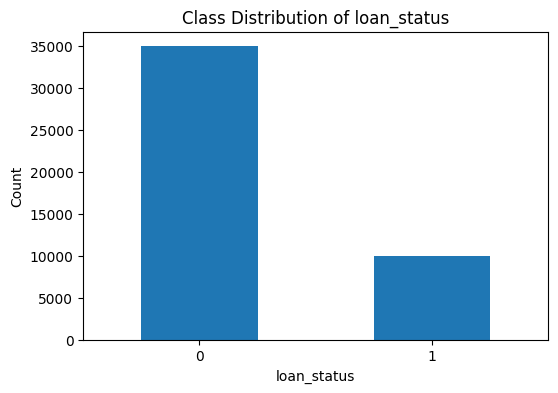

Class distribution (%):


,percentage
loan_status,
0,77.777778
1,22.222222


In [11]:
# Class distribution
plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution of loan_status")
plt.xlabel("loan_status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print("Class distribution (%):")
display(class_percent.rename("percentage").to_frame())

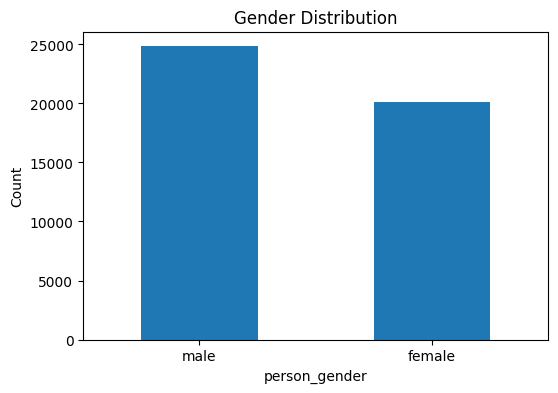

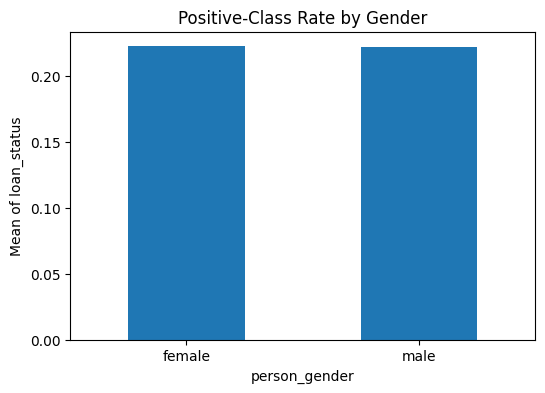

Gender summary:


,count,positive_class_rate
person_gender,,
female,20159,0.222481
male,24841,0.222012


Difference between highest and lowest gender positive-class rates: 0.0005


In [12]:
# Gender distribution and positive-class rate by gender
if "person_gender" in df.columns:
    gender_counts = df["person_gender"].value_counts()
    gender_rate = df.groupby("person_gender")[target_col].mean().sort_index()

    plt.figure(figsize=(6,4))
    gender_counts.plot(kind="bar")
    plt.title("Gender Distribution")
    plt.xlabel("person_gender")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

    plt.figure(figsize=(6,4))
    gender_rate.plot(kind="bar")
    plt.title("Positive-Class Rate by Gender")
    plt.xlabel("person_gender")
    plt.ylabel(f"Mean of {target_col}")
    plt.xticks(rotation=0)
    plt.show()

    gender_summary = pd.DataFrame({
        "count": gender_counts,
        "positive_class_rate": gender_rate
    })
    print("Gender summary:")
    display(gender_summary)

    if len(gender_rate) >= 2:
        print("Difference between highest and lowest gender positive-class rates:",
              round(float(gender_rate.max() - gender_rate.min()), 4))
else:
    print("Column 'person_gender' not found, so gender-based EDA was skipped.")

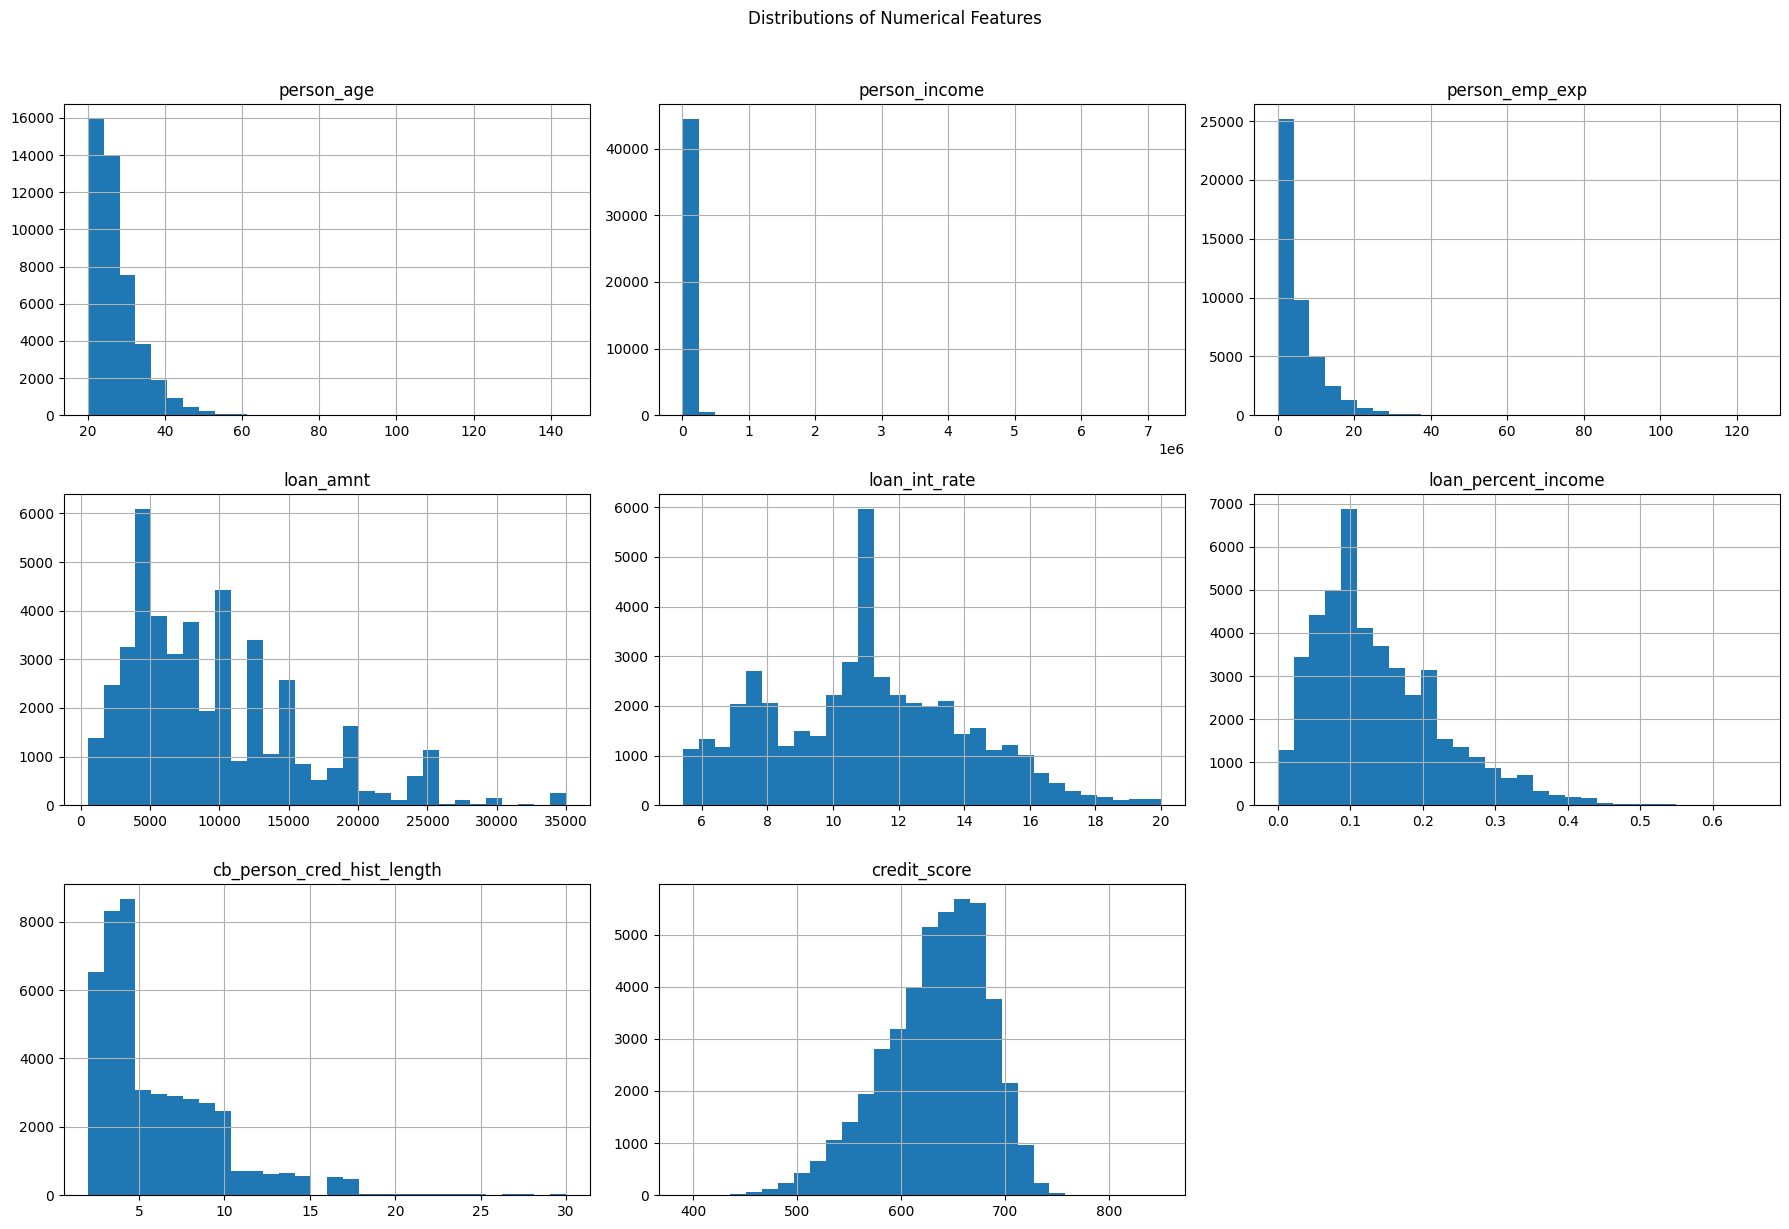

In [13]:
# Numerical feature distributions
df[numerical_feature_cols].hist(figsize=(18, 12), bins=30)
plt.suptitle("Distributions of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

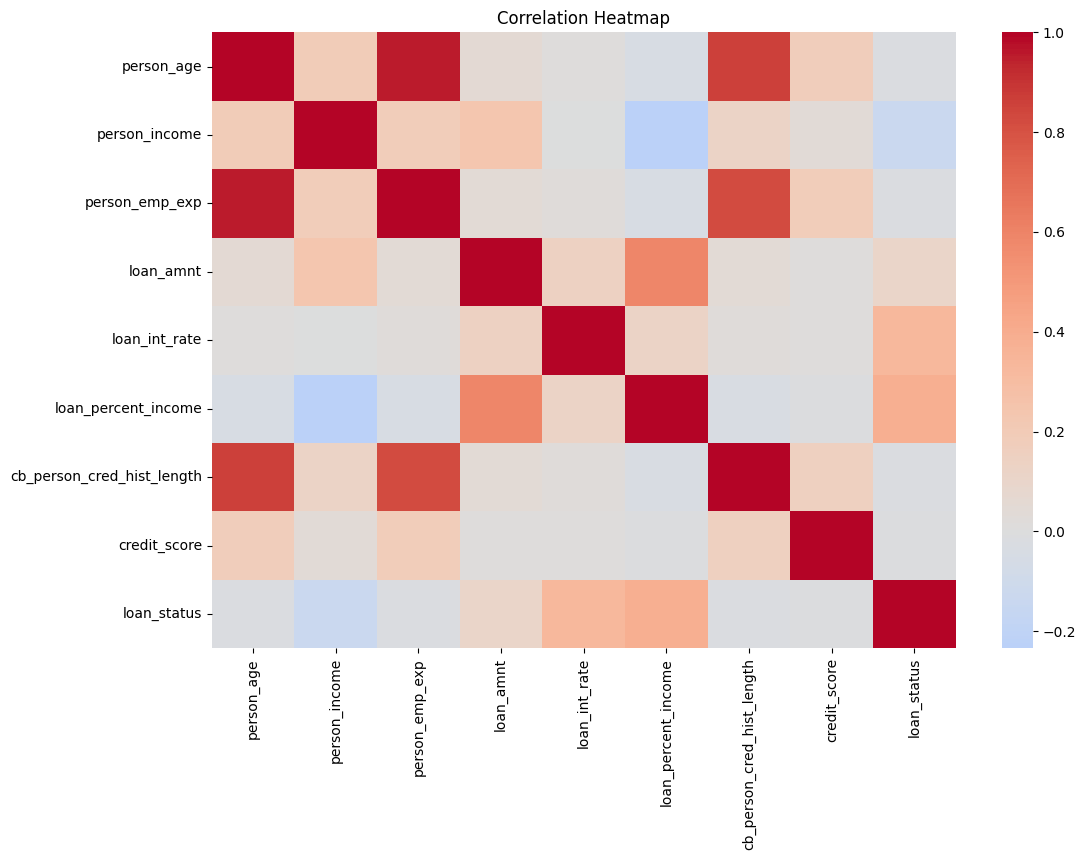

Correlation of numerical features with target:


,correlation_with_target
loan_percent_income,0.384880
loan_int_rate,0.332005
loan_amnt,0.107714
credit_score,-0.007647
cb_person_cred_hist_length,-0.014851
person_emp_exp,-0.020481
person_age,-0.021476
person_income,-0.135808


In [14]:
# Correlation heatmap for numerical columns
corr_df = df[numerical_feature_cols + [target_col]].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Correlation of features with target
target_corr = corr_df[target_col].drop(target_col).sort_values(ascending=False)
print("Correlation of numerical features with target:")
display(target_corr.to_frame(name="correlation_with_target"))

In [15]:
# IQR-based outlier detection
outlier_summary = []

for col in numerical_feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append({
        "feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_count),
        "outlier_percentage": round(outlier_percentage, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by="outlier_count", ascending=False)
print("IQR-based outlier summary:")
display(outlier_df)

IQR-based outlier summary:


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
3,loan_amnt,5000.00,12237.25,7237.25,-5855.875,23093.125,2348,5.22
1,person_income,47204.00,95789.25,48585.25,-25673.875,168667.125,2218,4.93
0,person_age,24.00,30.00,6.00,15.000,39.000,2188,4.86
2,person_emp_exp,1.00,8.00,7.00,-9.500,18.500,1724,3.83
6,cb_person_cred_hist_length,3.00,8.00,5.00,-4.500,15.500,1366,3.04
5,loan_percent_income,0.07,0.19,0.12,-0.110,0.370,744,1.65
7,credit_score,601.00,670.00,69.00,497.500,773.500,467,1.04
4,loan_int_rate,8.59,12.99,4.40,1.990,19.590,124,0.28


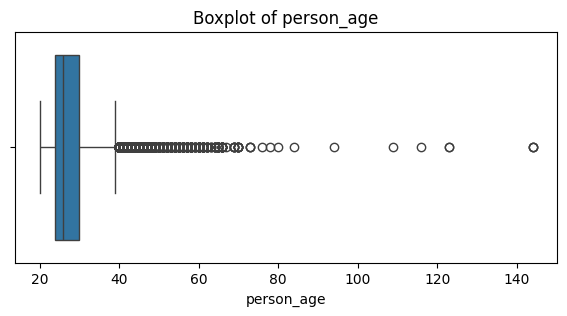

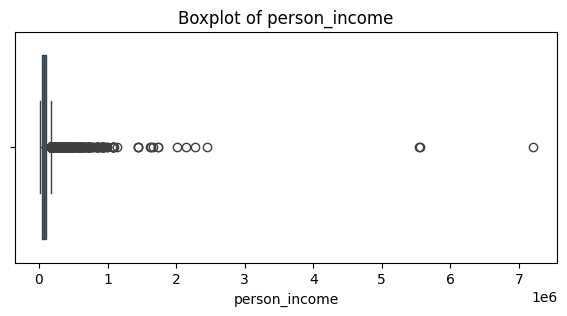

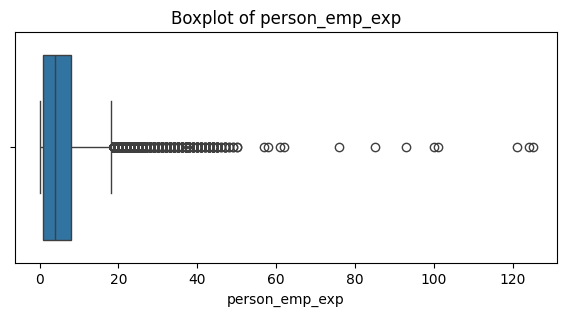

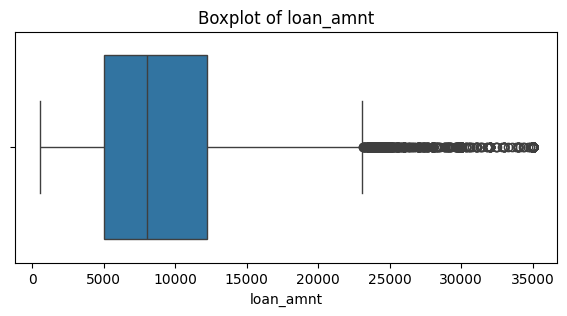

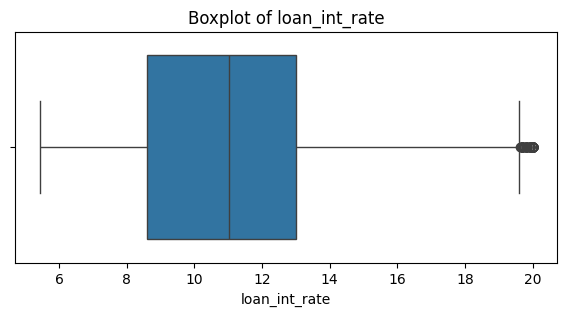

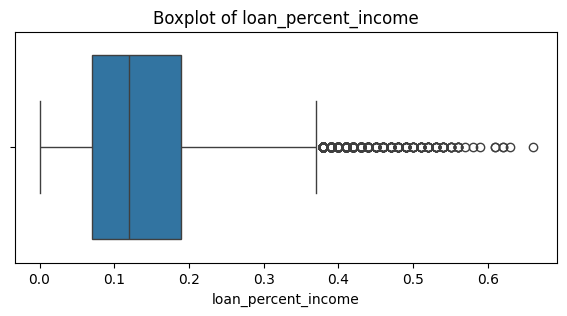

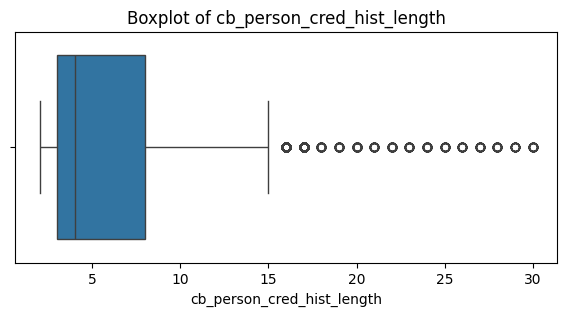

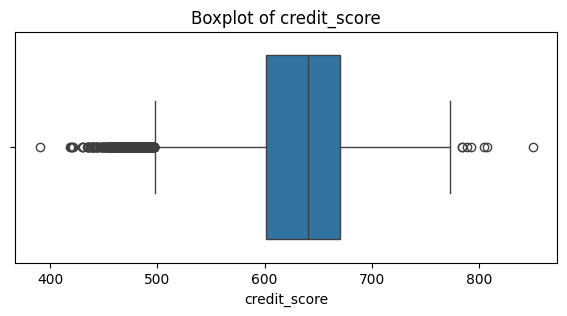

In [16]:
# Boxplots for numerical columns
for col in numerical_feature_cols:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 7. EDA Implications for Modeling and Evaluation

Based on the EDA results:
- class imbalance should be considered during evaluation
- gender-based subgroup analysis is relevant to the project objective
- correlated financial variables are likely to influence model predictions
- outliers exist in some numerical features, but they are retained to preserve realistic variation
- evaluation should not rely on accuracy alone

## 8. Relation to Prior Studies

The findings from this exploratory data analysis are consistent with the prior studies selected in Deliverable 2.

- **An Experimental Study on Fairness-Aware Machine Learning for Credit Scoring Problem (2024)** evaluates baseline and fairness-aware models using financial and demographic features. This aligns with the present dataset, where variables such as income, credit score, loan-to-income ratio, and previous default history appear strongly related to the target outcome.
- **Measuring Fairness in Credit Ratings (2024)** emphasizes that fairness outcomes are sensitive to feature relationships and data distribution. This is consistent with the current EDA, where class imbalance and feature correlations can affect model behavior and fairness evaluation.
- **Are Credit Scores Gender-Neutral? (2025)** shows that gender-related disparities may exist even when financial characteristics are comparable. This supports the gender-based subgroup analysis in this notebook.
- **Lending by Algorithm: Fair or Flawed? (2025)** evaluates automated lending outcomes across demographic groups, which supports the use of subgroup-aware evaluation and fairness metrics in this project.
- The broader review **Machine Learning Powered Financial Credit Scoring: A Systematic Literature Review (2025)** reports that structured tabular credit datasets are commonly modeled using classifiers such as Logistic Regression, Random Forest, Decision Tree, Gradient Boosting, along with metrics such as accuracy, precision, recall, F1-score, and AUC. This supports the methodological choices used in this project.

## 9. Preprocessing Pipeline for Modeling

To keep the modeling process methodologically clean:
- numerical columns → mean imputation + standardization
- categorical columns → mode imputation + one-hot encoding
- scaling is applied only to numerical columns
- categorical dummy variables are not manually scaled

In [17]:
X = df.drop(columns=[target_col])
y = df[target_col]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features used in preprocessing:")
print(numeric_features)

print("\nCategorical features used in preprocessing:")
print(categorical_features)

Numeric features used in preprocessing:
['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

Categorical features used in preprocessing:
['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


## 10. Evaluation Protocol Justification


This notebook uses:
- 80/20 train-test split
- stratification on the target variable
- 5-fold stratified cross-validation



In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().rename("proportion").to_frame())

print("Testing target distribution:")
display(y_test.value_counts(normalize=True).sort_index().rename("proportion").to_frame())

Training set shape: (36000, 13)
Testing set shape: (9000, 13)

Training target distribution:


,proportion
loan_status,
0,0.777778
1,0.222222


Testing target distribution:


,proportion
loan_status,
0,0.777778
1,0.222222


## 11. Baseline Model with Cross-Validation


Logistic Regression is used as a baseline model because it is one of the planned models in the project.

In [19]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    baseline_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=False
)

cv_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "mean_cv_score": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "std_cv_score": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

print("5-Fold Cross-Validation Summary:")
display(cv_summary)

5-Fold Cross-Validation Summary:


,metric,mean_cv_score,std_cv_score
0,accuracy,0.896200,0.001984
1,precision,0.776028,0.006693
2,recall,0.749200,0.004377
3,f1,0.762358,0.003971
4,roc_auc,0.954032,0.001609


## 12. Final Train/Test Evaluation

After cross-validation, the model is trained on the training split and evaluated on the held-out test split.
This gives one final estimate of predictive performance on unseen data.

In [20]:
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test F1 Score:", round(f1_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Actual_0", "Actual_1"],
    columns=["Pred_0", "Pred_1"]
))

Test Accuracy: 0.8993
Test F1 Score: 0.7673
Test ROC-AUC: 0.9562

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000

Confusion Matrix:


,Pred_0,Pred_1
Actual_0,6600,400
Actual_1,506,1494


# Phase 4: Feature Engineering

Feature engineering was applied to improve data representation and enhance model performance. The engineered features were based on insights from the exploratory data analysis (EDA) and common practices in financial risk modeling.

The following features were created:

- log_income: a logarithmic transformation of income to reduce skewness  
- high_debt_ratio: a binary feature indicating whether the loan-to-income ratio exceeds 30%  
- employment_stability: a binary feature indicating whether employment experience is greater than 5 years  
- credit_score_category: a categorical feature grouping credit scores into risk levels  

These features capture important financial characteristics and help models better learn patterns in the data.

In [21]:
df_fe = raw_df.copy()

# 1. Log transformation for income
# Helps reduce skewness in income values
df_fe['log_income'] = np.log1p(df_fe['person_income'])

# 2. High debt ratio indicator
# 1 = applicant has relatively high loan burden
df_fe['high_debt_ratio'] = (df_fe['loan_percent_income'] > 0.30).astype(int)

# 3. Employment stability indicator
# 1 = more stable employment history
df_fe['employment_stability'] = (df_fe['person_emp_exp'] > 5).astype(int)

# 4. Credit score category
# Groups credit score into broader creditworthiness bands
df_fe['credit_score_category'] = pd.cut(
    df_fe['credit_score'],
    bins=[300, 580, 670, 740, 850],
    labels=['poor', 'fair', 'good', 'excellent'],
    include_lowest=True
)

print("Feature engineering completed successfully.")
print("\nEngineered features added:")
print(['log_income', 'high_debt_ratio', 'employment_stability', 'credit_score_category'])

display(df_fe.head())

Feature engineering completed successfully.

Engineered features added:
['log_income', 'high_debt_ratio', 'employment_stability', 'credit_score_category']


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,log_income,high_debt_ratio,employment_stability,credit_score_category
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,11.183713,1,0,poor
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,9.415971,0,0,poor
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,9.428592,1,0,fair
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1,11.286702,1,0,good
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1,11.099469,1,0,fair


In [22]:
# Define input features and target
X = df_fe.drop(columns=['loan_status'])
y = df_fe['loan_status']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Feature matrix shape: (45000, 17)
Target shape: (45000,)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,log_income,high_debt_ratio,employment_stability,credit_score_category
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,11.183713,1,0,poor
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,9.415971,0,0,poor
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,9.428592,1,0,fair
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,11.286702,1,0,good
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,11.099469,1,0,fair


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (36000, 17)
Test shape: (9000, 17)


# 2.Preprocessing pipeline


The preprocessing pipeline was constructed by separating features into numerical and categorical groups. Numerical features were processed using mean imputation followed by standardization. Categorical features were handled using mode imputation and one-hot encoding. These transformations were combined using a ColumnTransformer to ensure consistent preprocessing across all models.

In [24]:
# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Numerical features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'log_income', 'high_debt_ratio', 'employment_stability']
Categorical features: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file', 'credit_score_category']


# 3.Baseline models

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 4.Train and evaluate baseline models

In [26]:
results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, f1, roc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-score", "ROC-AUC"])
print("Initial Baseline Results:")
display(results_df)

Initial Baseline Results:


,Model,Accuracy,F1-score,ROC-AUC
0,Logistic Regression,0.903000,0.777693,0.957484
1,Decision Tree,0.898000,0.772095,0.854964
2,Random Forest,0.930000,0.830918,0.975585
3,Gradient Boosting,0.923222,0.814696,0.972268


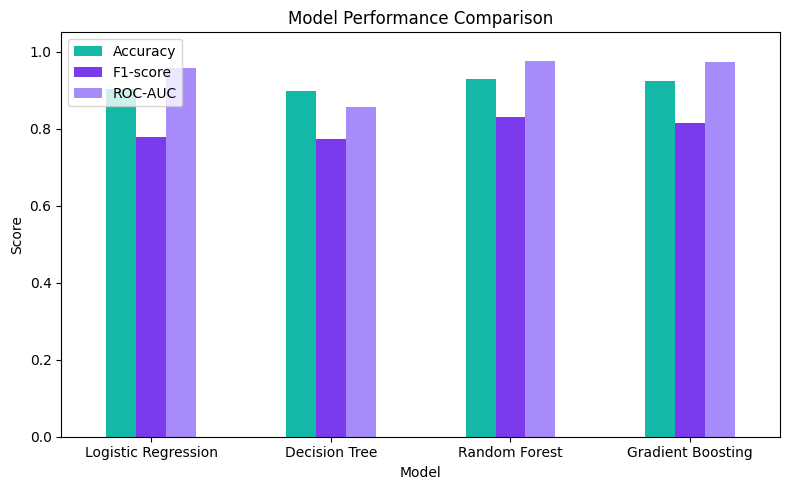

In [27]:
# Figure 1: Model Performance Comparison

results_df.set_index("Model")[["Accuracy", "F1-score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(8,5),
    color=["#14b8a6", "#7c3aed", "#a78bfa"]
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# 5.Cross-validation


Stratified 5-fold cross-validation was applied to evaluate model performance using the F1-score. This approach ensures that each fold preserves the class distribution and provides a more reliable estimate of model performance across different data splits.

In [28]:
print("5-Fold Cross-Validation Results (F1-score):\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(clf, X, y, cv=cv, scoring='f1')
    print(f"{name}: Mean F1-score = {scores.mean():.4f}")

5-Fold Cross-Validation Results (F1-score):

Logistic Regression: Mean F1-score = 0.7682
Decision Tree: Mean F1-score = 0.7733
Random Forest: Mean F1-score = 0.8280
Gradient Boosting: Mean F1-score = 0.8159


# 6.Detailed reports for each model


Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.76      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.86      9000
weighted avg       0.90      0.90      0.90      9000

Confusion Matrix:
[[6600  400]
 [ 473 1527]]

Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      7000
           1       0.77      0.78      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000

Confusion Matrix:
[[6527  473]
 [ 445 1555]]

Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7000
           1       0.90 

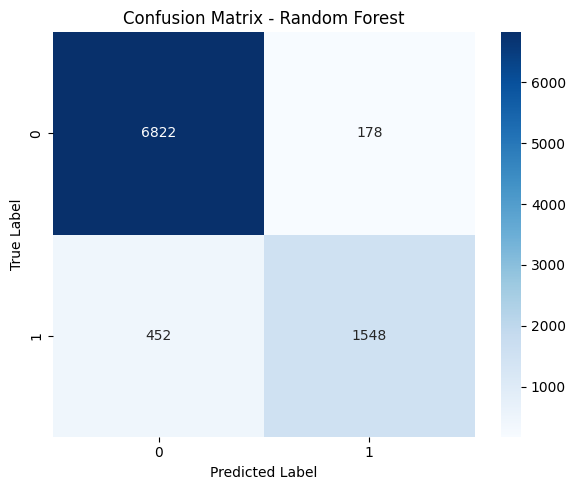


Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7000
           1       0.88      0.76      0.81      2000

    accuracy                           0.92      9000
   macro avg       0.91      0.86      0.88      9000
weighted avg       0.92      0.92      0.92      9000

Confusion Matrix:
[[6790  210]
 [ 481 1519]]


In [29]:
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")

    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Figure 2 shown only for Random Forest (best model)
    if name == "Random Forest":
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

        plt.title("Confusion Matrix - Random Forest")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")

        plt.tight_layout()
        plt.show()

# Fairness metrics

In [30]:
X = df_fe.drop(columns=["loan_status"])
y = df_fe["loan_status"]
gender = df_fe["person_gender"]

X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X,
    y,
    gender,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [32]:
def fairness_metrics(y_true, y_pred, gender):
    df_eval = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "gender": gender.values
    })

    groups = df_eval["gender"].unique()
    g1, g2 = groups[0], groups[1]

    def positive_rate(d):
        return (d["y_pred"] == 1).mean()

    def true_positive_rate(d):
        pos = d[d["y_true"] == 1]
        if len(pos) == 0:
            return 0
        return (pos["y_pred"] == 1).mean()

    ppr1 = positive_rate(df_eval[df_eval["gender"] == g1])
    ppr2 = positive_rate(df_eval[df_eval["gender"] == g2])

    tpr1 = true_positive_rate(df_eval[df_eval["gender"] == g1])
    tpr2 = true_positive_rate(df_eval[df_eval["gender"] == g2])

    return {
        "Demographic Parity Difference": abs(ppr1 - ppr2),
        "Disparate Impact Ratio": (ppr1 / ppr2) if ppr2 != 0 else np.nan,
        "Equal Opportunity Difference": abs(tpr1 - tpr2)
    }

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [34]:
fairness_results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)

    metrics = fairness_metrics(y_test, preds, gender_test)
    metrics["Model"] = name
    fairness_results.append(metrics)

fairness_df = pd.DataFrame(fairness_results)

fairness_df = fairness_df[[
    "Model",
    "Demographic Parity Difference",
    "Disparate Impact Ratio",
    "Equal Opportunity Difference"
]]

fairness_df

,Model,Demographic Parity Difference,Disparate Impact Ratio,Equal Opportunity Difference
0,Logistic Regression,0.000150,1.000699,0.002103
1,Decision Tree,0.007194,0.968515,0.000031
2,Random Forest,0.002511,0.986983,0.006123
3,Gradient Boosting,0.005812,0.970142,0.008965
